In [ ]:
import numpy as np
import pandas as pd

In [ ]:
# linking the data set with pandas 
df = pd.read_csv("netflix-699bb0d94f78e745148155.csv")
df


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [ ]:
# cheking data types
df.dtypes

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

In [ ]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [ ]:
#detect the missing values
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [ ]:
#groupig data by type
df.groupby(['type']).count()

,show_id,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
type,,,,,,,,,,,
Movie,6131,6131,5943,5656,5691,6131,6131,6129,6128,6131,6131
TV Show,2676,2676,230,2326,2285,2666,2676,2674,2676,2676,2676


In [ ]:
# for i in df['reting']:
#     if i == 'PG-13'or 'TV-MA'or 'PG'or 'TV-14'or 'TV-PG'or 'TV-Y'or 'TV-Y7'or 'R'or'TV-G'or 'G'or 'NC-17'or 'NR'or 'TV-Y7-FV'or 'UR':
#         continue
#     else:
#         df['duration'] = df.fillna(i , inplace= True)

In [ ]:
#fixing date errors
values = ['74 min','84 min','66 min']
mask = df['rating'].isin(values)
df.loc[mask,'duration'] = df.loc[mask,'rating']
df.loc[mask,'rating']= np.nan 

In [ ]:
#detect the unique values
df["rating"].unique()

array(['PG-13', 'TV-MA', 'PG', 'TV-14', 'TV-PG', 'TV-Y', 'TV-Y7', 'R',
       'TV-G', 'G', 'NC-17', nan, 'NR', 'TV-Y7-FV', 'UR'], dtype=object)

In [ ]:
#replace the missing values from reting colum by the mode
x = df["rating"].mode()[0]
df["rating"].fillna(x, inplace=True)

C:\Users\oussama\AppData\Local\Temp\ipykernel_5724\3049622580.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["rating"].fillna(x, inplace=True)


In [ ]:
#fixing the date format

df['date_added'] = df["date_added"].str.strip()
df['date_added'] = pd.to_datetime(df['date_added'], format = 'mixed')
df['date_added']

0      2021-09-25
1      2021-09-24
2      2021-09-24
3      2021-09-24
4      2021-09-24
          ...    
8802   2019-11-20
8803   2019-07-01
8804   2019-11-01
8805   2020-01-11
8806   2019-03-02
Name: date_added, Length: 8807, dtype: datetime64[ns]

In [ ]:
df['date_year']=pd.to_datetime(df['date_added'],errors='coerce').dt.year

In [ ]:
#plun all missing values by not founded
df.fillna('Not found', inplace= True)

C:\Users\oussama\AppData\Local\Temp\ipykernel_5724\1586325330.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Not found' has dtype incompatible with datetime64[ns], please explicitly cast to a compatible dtype first.
  df.fillna('Not found', inplace= True)
C:\Users\oussama\AppData\Local\Temp\ipykernel_5724\1586325330.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Not found' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.fillna('Not found', inplace= True)


In [ ]:
import matplotlib.pyplot as plt

Text(0, 0.5, 'Distribution of content')

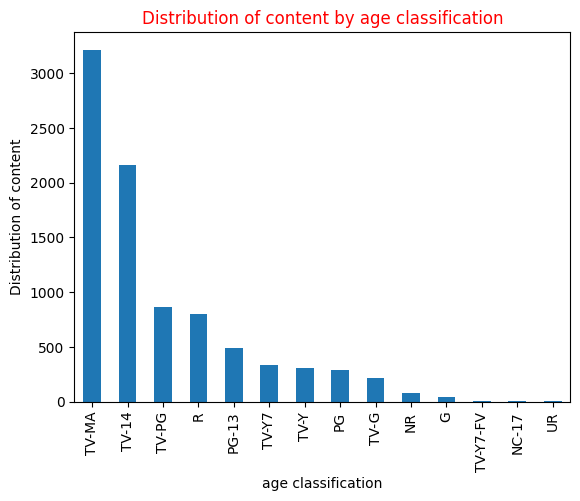

In [ ]:
df['rating'].value_counts().plot.bar()
plt.Figure(figsize=(16, 20))
plt.title("Distribution of content by age classification", c = 'red')
plt.xlabel('age classification', c = 'k')
plt.ylabel('Distribution of content')


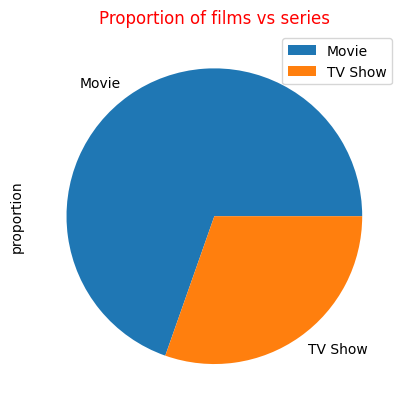

In [ ]:
df['type'].value_counts(normalize=True).plot.pie()

plt.title('Proportion of films vs series', c = 'red')
plt.legend()

Text(0, 0.5, 'Number of items')

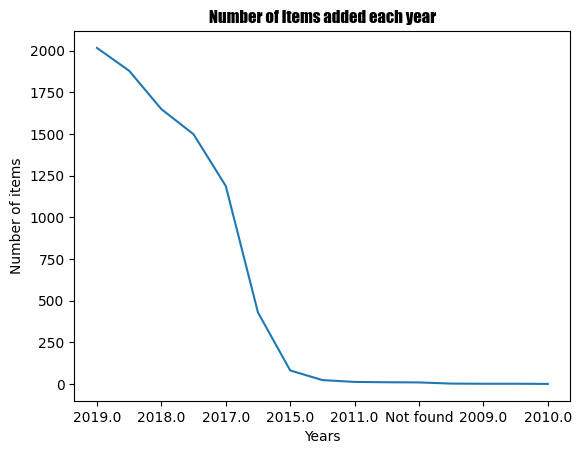

In [ ]:
df['date_year'].value_counts().plot.line()

plt.title('Number of items added each year', fontname = 'impact')
plt.xlabel('Years')
plt.ylabel('Number of items')

In [ ]:
import seaborn as sb


TypeError: lineplot() takes from 0 to 1 positional arguments but 2 were given